In [1]:
pip install torch torchvision albumentations ultralytics grad-cam gradio scikit-learn matplotlib seaborn wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.8 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=d31638dae136b0cf19a3f54954090e22af21d9111706638f3546023eb50bef49
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
!pip install kaggle

In [4]:
!pip install kaggle
!mkdir -p ~/.kaggle

In [6]:
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d kaustubhdikshit/neu-surface-defect-database
!unzip -q neu-surface-defect-database.zip -d data/

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
100% 26.4M/26.4M [00:00<00:00, 159MB/s] 



In [7]:
!find data -maxdepth 3 -type d

data
data/NEU-DET
data/NEU-DET/train
data/NEU-DET/train/annotations
data/NEU-DET/train/images
data/NEU-DET/validation
data/NEU-DET/validation/annotations
data/NEU-DET/validation/images


In [9]:
!mkdir -p src models outputs

In [35]:
import sys, os, glob
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

class NEUDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.transform = transform
        for idx, cls in enumerate(CLASSES):
            for f in glob.glob(os.path.join(root, cls, '*.jpg')):
                self.samples.append((f, idx))
            for f in glob.glob(os.path.join(root, f'{cls}*.jpg')):
                self.samples.append((f, idx))
        self.samples = list(set(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        img = self.transform(image=np.array(img))['image']
        return img, label

train_tf = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

def get_loaders(root, batch_size=32):
    full = NEUDataset(root, transform=train_tf)
    n = len(full)
    n_train, n_val = int(0.7 * n), int(0.15 * n)
    train_ds, val_ds, test_ds = random_split(
        full, [n_train, n_val, n - n_train - n_val],
        generator=torch.Generator().manual_seed(42)
    )
    val_ds.dataset.transform = val_tf
    test_ds.dataset.transform = val_tf
    return (DataLoader(train_ds, batch_size, shuffle=True, num_workers=2),
            DataLoader(val_ds, batch_size, num_workers=2),
            DataLoader(test_ds, batch_size, num_workers=2))

In [36]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        def block(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc),
                nn.ReLU(), nn.MaxPool2d(2))
        self.features = nn.Sequential(
            block(3, 32), block(32, 64), block(64, 128), block(128, 256))
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3), nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

In [37]:
def train_model(model, data_root, epochs=25, lr=1e-3, name='baseline'):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    train_dl, val_dl, test_dl = get_loaders(data_root)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss()
    best_acc = 0
    os.makedirs('models', exist_ok=True)

    for ep in range(epochs):
        model.train()
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
        sched.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        acc = correct / total
        print(f'epoch {ep+1}/{epochs}  val_acc={acc:.4f}')
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), f'models/{name}_best.pt')
    return test_dl

In [39]:
data_root = 'data/NEU-DET/train/images'
test_dl = train_model(BaselineCNN(), data_root, name='baseline')

epoch 1/25  val_acc=0.4074
epoch 2/25  val_acc=0.8657
epoch 3/25  val_acc=0.8426
epoch 4/25  val_acc=0.8611
epoch 5/25  val_acc=0.8796
epoch 6/25  val_acc=0.8657
epoch 7/25  val_acc=0.8426
epoch 8/25  val_acc=0.9306
epoch 9/25  val_acc=0.9306
epoch 10/25  val_acc=0.8426
epoch 11/25  val_acc=0.8380
epoch 12/25  val_acc=0.8935
epoch 13/25  val_acc=0.9398
epoch 14/25  val_acc=0.9491
epoch 15/25  val_acc=0.9491
epoch 16/25  val_acc=0.9722
epoch 17/25  val_acc=0.9722
epoch 18/25  val_acc=0.9676
epoch 19/25  val_acc=0.9722
epoch 20/25  val_acc=1.0000
epoch 21/25  val_acc=0.9861
epoch 22/25  val_acc=0.9861
epoch 23/25  val_acc=0.9954
epoch 24/25  val_acc=0.9954
epoch 25/25  val_acc=0.9954


In [40]:
from torchvision import models

def get_resnet(num_classes=6):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

test_dl = train_model(get_resnet(), data_root, epochs=15, lr=3e-4, name='resnet18')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


epoch 1/15  val_acc=0.9583
epoch 2/15  val_acc=0.9583
epoch 3/15  val_acc=0.9907
epoch 4/15  val_acc=0.9954
epoch 5/15  val_acc=1.0000
epoch 6/15  val_acc=1.0000
epoch 7/15  val_acc=0.9954
epoch 8/15  val_acc=0.9954
epoch 9/15  val_acc=1.0000
epoch 10/15  val_acc=1.0000
epoch 11/15  val_acc=1.0000
epoch 12/15  val_acc=1.0000
epoch 13/15  val_acc=1.0000
epoch 14/15  val_acc=1.0000
epoch 15/15  val_acc=1.0000


                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        34
      inclusion       0.98      1.00      0.99        41
        patches       1.00      1.00      1.00        32
 pitted_surface       1.00      1.00      1.00        37
rolled-in_scale       1.00      1.00      1.00        39
      scratches       1.00      0.97      0.99        34

       accuracy                           1.00       217
      macro avg       1.00      1.00      1.00       217
   weighted avg       1.00      1.00      1.00       217



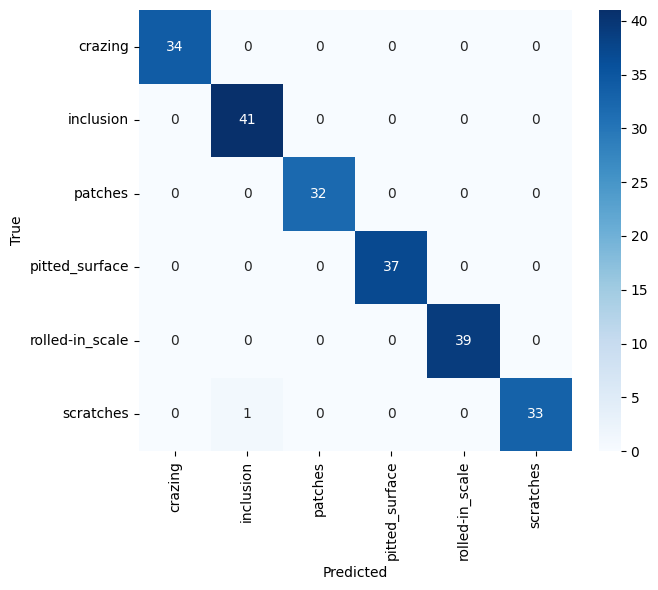

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = get_resnet().to(device)
model.load_state_dict(torch.load('models/resnet18_best.pt'))
model.eval()

preds, labels = [], []
with torch.no_grad():
    for x, y in test_dl:
        preds += model(x.to(device)).argmax(1).cpu().tolist()
        labels += y.tolist()

print(classification_report(labels, preds, target_names=CLASSES))

os.makedirs('outputs', exist_ok=True)
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()

In [43]:
import xml.etree.ElementTree as ET

ANN_DIR = 'data/NEU-DET/train/annotations'   # adjust if your find output differs
YOLO_LBL_DIR = 'data/yolo/labels/all'
os.makedirs(YOLO_LBL_DIR, exist_ok=True)

converted = 0
for xml_file in glob.glob(f'{ANN_DIR}/*.xml'):
    root = ET.parse(xml_file).getroot()
    W = int(root.find('size/width').text)
    H = int(root.find('size/height').text)
    lines = []
    for obj in root.findall('object'):
        cls = obj.find('name').text
        if cls not in CLASSES:
            continue
        b = obj.find('bndbox')
        x1, y1 = float(b.find('xmin').text), float(b.find('ymin').text)
        x2, y2 = float(b.find('xmax').text), float(b.find('ymax').text)
        cx, cy = (x1 + x2) / 2 / W, (y1 + y2) / 2 / H
        w, h = (x2 - x1) / W, (y2 - y1) / H
        lines.append(f'{CLASSES.index(cls)} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')
    name = os.path.splitext(os.path.basename(xml_file))[0]
    with open(f'{YOLO_LBL_DIR}/{name}.txt', 'w') as f:
        f.write('\n'.join(lines))
    converted += 1

print(f'converted {converted} annotation files')

converted 1439 annotation files


In [44]:
import random, shutil

random.seed(42)
all_imgs = glob.glob(f'{data_root}/**/*.jpg', recursive=True)
random.shuffle(all_imgs)
split = int(0.85 * len(all_imgs))
splits = {'train': all_imgs[:split], 'val': all_imgs[split:]}

for subset, files in splits.items():
    os.makedirs(f'data/yolo/images/{subset}', exist_ok=True)
    os.makedirs(f'data/yolo/labels/{subset}', exist_ok=True)
    for img in files:
        name = os.path.splitext(os.path.basename(img))[0]
        lbl_src = f'{YOLO_LBL_DIR}/{name}.txt'
        if os.path.exists(lbl_src):
            shutil.copy(img, f'data/yolo/images/{subset}/')
            shutil.copy(lbl_src, f'data/yolo/labels/{subset}/')

print('train imgs:', len(os.listdir('data/yolo/images/train')))
print('val imgs:', len(os.listdir('data/yolo/images/val')))

train imgs: 1223
val imgs: 216


In [45]:
yaml_content = """path: data/yolo
train: images/train
val: images/val
names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""
with open('neu.yaml', 'w') as f:
    f.write(yaml_content)
print(yaml_content)

path: data/yolo
train: images/train
val: images/val
names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches



In [46]:
!pip install ultralytics

In [47]:
from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt')
yolo_model.train(data='neu.yaml', epochs=100, imgsz=224, batch=32)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=neu.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eee45983980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [48]:
metrics = yolo_model.val(data='neu.yaml')
print(metrics.box.map, metrics.box.map50)  # mAP@0.5:0.95, mAP@0.5

results = yolo_model.predict(source='data/yolo/images/val', save=True, conf=0.25)
print('predictions saved to:', results[0].save_dir)

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 775.6±358.4 MB/s, size: 16.1 KB)
val: Scanning /content/data/yolo/labels/val.cache... 216 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 216/216 90.6Mit/s 0.0s
val: /content/data/yolo/images/val/crazing_120.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 7.1it/s 2.0s
                   all        216        509      0.674      0.697      0.743       0.43
               crazing         49        112      0.517      0.277      0.397      0.162
             inclusion         38        122      0.707      0.836      0.873      0.452
               patches         30         82      0.852      0.927      0.942      0.631
        pitted_surface         30         39      0.669     

In [49]:
!pip install grad-cam

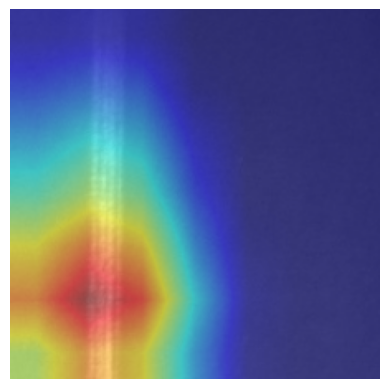

In [50]:
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

img_path = glob.glob(f'{data_root}/**/*.jpg', recursive=True)[0]  # pick any test image
raw = np.array(Image.open(img_path).convert('RGB').resize((224, 224))) / 255.0
x = val_tf(image=(raw * 255).astype(np.uint8))['image'].unsqueeze(0).to(device)

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])
heatmap = cam(input_tensor=x)[0]
overlay = show_cam_on_image(raw.astype(np.float32), heatmap, use_rgb=True)

cv2.imwrite('outputs/gradcam.png', cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
plt.imshow(overlay); plt.axis('off'); plt.show()

In [51]:
os.makedirs('deploy_models', exist_ok=True)
shutil.copy('models/resnet18_best.pt', 'deploy_models/resnet18_best.pt')
shutil.copy(str(yolo_model.trainer.best), 'deploy_models/yolo_best.pt')
print(os.listdir('deploy_models'))

['resnet18_best.pt', 'yolo_best.pt']


In [52]:
!pip install gradio

In [53]:
import gradio as gr

clf_demo = get_resnet()
clf_demo.load_state_dict(torch.load('deploy_models/resnet18_best.pt', map_location='cpu'))
clf_demo.eval()
det_demo = YOLO('deploy_models/yolo_best.pt')

def analyze(img):
    x = val_tf(image=np.array(img))['image'].unsqueeze(0)
    with torch.no_grad():
        probs = torch.softmax(clf_demo(x), 1)[0]
    cls_out = {CLASSES[i]: float(probs[i]) for i in range(6)}
    annotated = det_demo(img)[0].plot()[:, :, ::-1]  # BGR->RGB
    return cls_out, annotated

demo = gr.Interface(
    fn=analyze,
    inputs=gr.Image(type='pil', label='SEM micrograph'),
    outputs=[gr.Label(num_top_classes=3, label='Defect class'),
             gr.Image(label='YOLO detections')],
    title='Steel Surface Defect Detection',
    description='CNN classification + YOLOv8 detection for automated non-destructive inspection.'
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f76e0f5fc0a291b47e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [54]:
requirements = """torch
torchvision
ultralytics
albumentations
gradio
grad-cam
opencv-python-headless
"""
with open('requirements.txt', 'w') as f:
    f.write(requirements)